In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px


In [3]:
df = pd.read_csv('Netflix_Dataset.csv')

In [4]:
print(df.head())


  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_Date Rating   Duration  \
0    August 14, 2020  TV-MA  4 Seasons   
1  December 23, 2016  TV-MA     93 min   
2  December 20, 2018      R     78 min   
3  November 16, 2017  PG-13     80 min   
4    January 1, 2020  PG-13    123 min   

                               

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [6]:
df.duplicated().value_counts()


False    7787
True        2
Name: count, dtype: int64

In [7]:
print(df[df.duplicated()])

     Show_Id Category              Title        Director  \
6300    s684    Movie           Backfire     Dave Patten   
6622   s6621    Movie  The Lost Okoroshi  Abba T. Makama   

                                                   Cast        Country  \
6300  Black Deniro, Byron "Squally" Vinson, Dominic ...  United States   
6622  Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...        Nigeria   

           Release_Date Rating Duration  \
6300      April 5, 2019  TV-MA   97 min   
6622  September 4, 2020  TV-MA   94 min   

                                       Type  \
6300  Dramas, Independent Movies, Thrillers   
6622   Comedies, Dramas, Independent Movies   

                                            Description  
6300  When two would-be robbers accidentally kill a ...  
6622  A disillusioned security guard transforms into...  


In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().value_counts()

False    7787
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7787 non-null   object
 1   Category      7787 non-null   object
 2   Title         7787 non-null   object
 3   Director      5399 non-null   object
 4   Cast          7069 non-null   object
 5   Country       7280 non-null   object
 6   Release_Date  7777 non-null   object
 7   Rating        7780 non-null   object
 8   Duration      7787 non-null   object
 9   Type          7787 non-null   object
 10  Description   7787 non-null   object
dtypes: object(11)
memory usage: 730.0+ KB


In [11]:
df['Release_Date'] = df['Release_Date'].str.replace(',','', regex=False)

In [12]:
df['Year'] = pd.to_datetime(df['Release_Date'], errors='coerce').dt.year


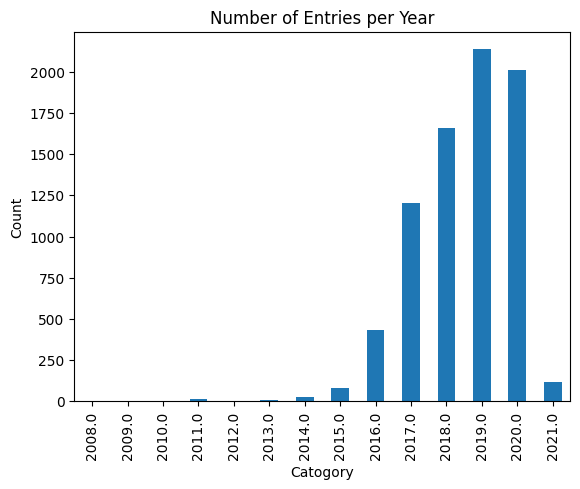

In [13]:
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Catogory')
plt.ylabel('Count')
plt.title('Number of Entries per Year')
plt.show()

In [ ]:
movies_tv_by_year = df.groupby(['Year', 'Category']).size().reset_index(name='Count')

C:\Users\hp\AppData\Local\Temp\ipykernel_6884\4083515329.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=movies_tv_by_year, x='Year', y='Count', hue='Category', ci=None)


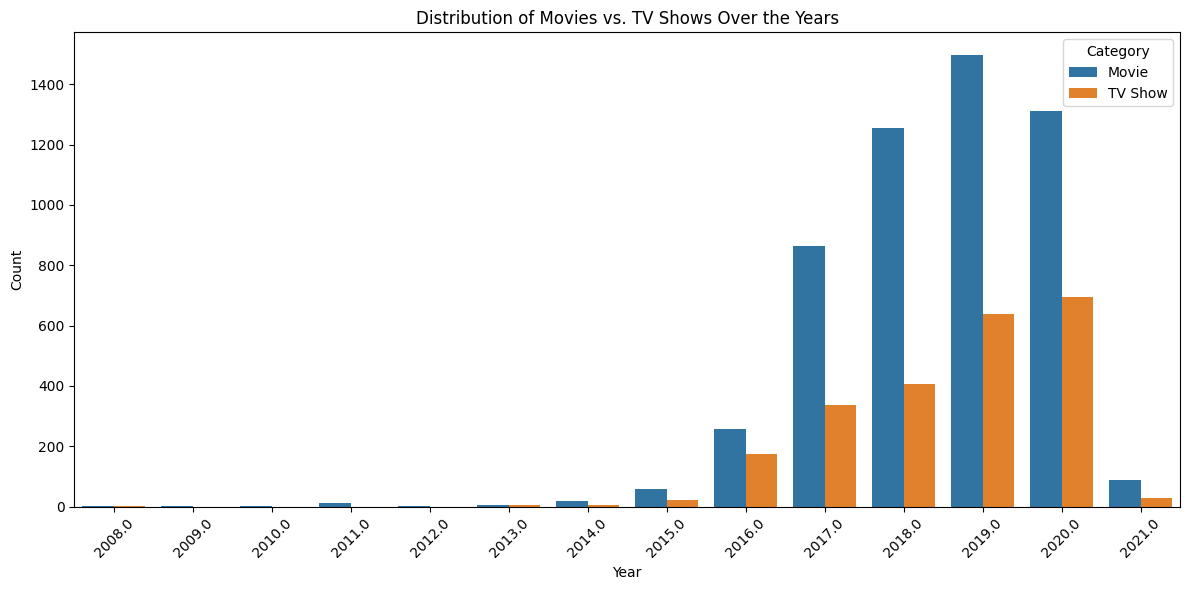

In [ ]:

plt.figure(figsize=(12,6))
sns.barplot(data=movies_tv_by_year, x='Year', y='Count', hue='Category', ci=None)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of Movies vs. TV Shows Over the Years')
plt.legend(title='Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

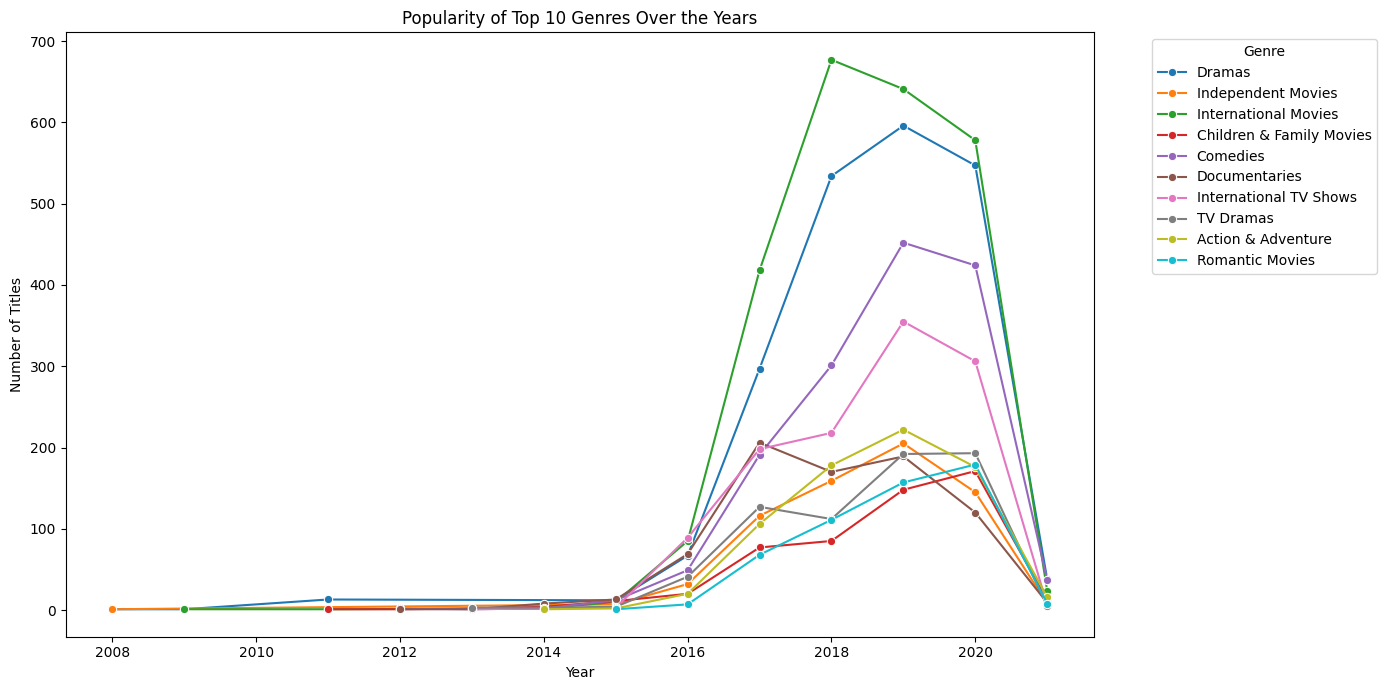

In [16]:
# Split the 'Type' column (genres) and explode to get one genre per row
df_genres = df.copy()
df_genres['Genre'] = df_genres['Type'].str.split(',').apply(lambda x: [g.strip() for g in x])
df_genres = df_genres.explode('Genre')

# Find the most common genres overall
top_genres = df_genres['Genre'].value_counts().head(10).index.tolist()

# Filter to only top genres for clearer plots
df_top_genres = df_genres[df_genres['Genre'].isin(top_genres)]

# Group by Year and Genre, count occurrences
genre_trends = df_top_genres.groupby(['Year', 'Genre']).size().reset_index(name='Count')

plt.figure(figsize=(14,7))
sns.lineplot(data=genre_trends, x='Year', y='Count', hue='Genre', marker='o')
plt.title('Popularity of Top 10 Genres Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_6884\1159740098.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


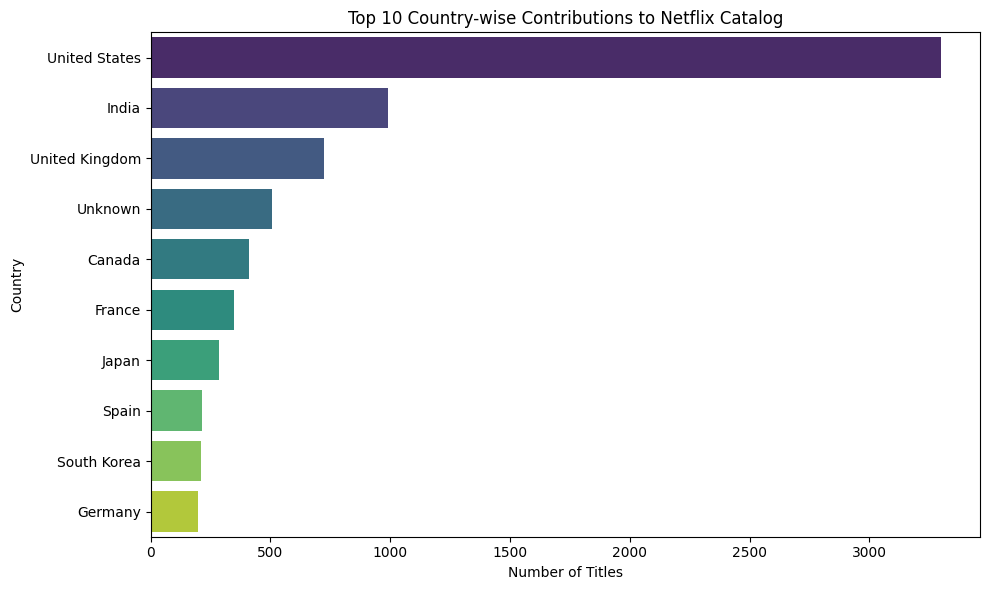

In [17]:
# Split the 'Country' column and explode to get one country per row
df_countries = df.copy()
df_countries['Country'] = df_countries['Country'].fillna('Unknown')
df_countries['Country'] = df_countries['Country'].str.split(',').apply(lambda x: [c.strip() for c in x])
df_countries = df_countries.explode('Country')

# Find the top 10 contributing countries
top_countries = df_countries['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.title('Top 10 Country-wise Contributions to Netflix Catalog')
plt.tight_layout()
plt.show()

## Insights and Strategic Recommendations

### How Netflix’s Content Strategy Has Evolved
- The number of both Movies and TV Shows has increased over the years, with notable growth in recent years.
- The catalog is increasingly diverse, with contributions from many countries, though the US remains dominant.
- The most common genres include Dramas, International Movies/TV Shows, Comedies, and Documentaries, with some genres rising or falling in popularity over time.

### Top-Performing Genres and Categories
- Dramas and International content are consistently among the most popular genres.
- TV Shows have seen a significant rise, reflecting the global trend toward serialized content.
- Comedies and Documentaries are also strong performers, appealing to a wide audience.

### Strategic Recommendations for Netflix
- Continue investing in International content to attract a global audience and differentiate from competitors.
- Focus on Dramas and TV Shows, as these categories show sustained and growing popularity.
- Expand genre diversity, but prioritize top-performing genres like Dramas, Comedies, and Documentaries.
- Explore emerging genres and monitor trends to quickly adapt to changing viewer preferences.
- Leverage data on country-wise contributions to identify underrepresented markets with growth potential.

These insights can help guide Netflix’s future content acquisition and production strategy for maximum engagement and growth.